# Dynamic MMF data maker for MMDN

This notebook generates the dataset expected by `MMDN.py`:

- `pattern.npy`: target binary input images, shape `(N, 256)` for 16x16 patterns.
- `speckles.npy`: output speckle intensity images, shape `(N, 100, 100)`.
- `time_index.npy`: sample time/state index, with `0` reserved for pretraining.
- `kappa_per_sample.npy`: curvature value for each sample.
- `metadata.json`: reproducibility and training settings.

Unlike the previous HDF5 maker, this notebook does not write `M`, `Tm`, modal coefficients, or probe fields to disk. The mode matrix and transmission matrices are only held in memory while generating samples.

In [1]:
# Environment setup: locate pyMMF and local fast_tm.py.
from pathlib import Path
import sys
import zipfile

ROOT = Path.cwd().resolve()


def _is_pymmf_repo(path):
    path = Path(path)
    return (path / "pyMMF" / "__init__.py").exists()


def _is_pymmf_package(path):
    path = Path(path)
    return path.name == "pyMMF" and (path / "__init__.py").exists()


def _find_pymmf_repo():
    candidates = [
        ROOT / "pyMMF",
        ROOT.parent / "pyMMF",
        ROOT / "MMF_simulation_lab" / "pyMMF",
        ROOT.parent / "MMF_simulation_lab" / "pyMMF",
        ROOT,
    ]
    for candidate in candidates:
        if _is_pymmf_repo(candidate):
            return candidate.resolve()
        if _is_pymmf_package(candidate):
            return candidate.parent.resolve()
    return None


def _extract_pymmf_if_needed():
    repo = _find_pymmf_repo()
    if repo is not None:
        return repo

    zip_candidates = [ROOT / "pyMMF.zip", *sorted(ROOT.glob("*pyMMF*.zip"))]
    zip_candidates = [p for p in zip_candidates if p.exists()]
    if not zip_candidates:
        raise FileNotFoundError(
            "pyMMF was not found. Put a pyMMF directory in this folder or its parent, "
            "or put pyMMF.zip in the same folder as this notebook."
        )

    archive = zip_candidates[0]
    print(f"pyMMF directory not found; extracting {archive.name} into {ROOT}")
    with zipfile.ZipFile(archive, "r") as zf:
        for member in zf.infolist():
            target = (ROOT / member.filename).resolve()
            try:
                target.relative_to(ROOT)
            except ValueError as exc:
                raise RuntimeError(f"Unsafe path in zip archive: {member.filename}") from exc
        zf.extractall(ROOT)

    repo = _find_pymmf_repo()
    if repo is None:
        raise FileNotFoundError(
            f"Extracted {archive}, but could not find a valid pyMMF package. "
            "Expected either pyMMF/pyMMF/__init__.py or pyMMF/__init__.py."
        )
    return repo


PYMMF_REPO = _extract_pymmf_if_needed()
for p in [PYMMF_REPO, ROOT, ROOT / "speed_bn"]:
    if Path(p).exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("cwd:", ROOT)
print("pyMMF repo:", PYMMF_REPO)

cwd: C:\Users\GG152\Desktop\sustech_2\ML\course project\自选\数据集
pyMMF repo: C:\Users\GG152\Desktop\sustech_2\ML\course project\自选\数据集\pyMMF


In [2]:
import json
import logging
import math
import os
import time
import warnings
from pathlib import Path

import numpy as np
import scipy.linalg
import scipy.ndimage
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

import pyMMF

SUPPRESS_PYMMF_LOGS = True
if SUPPRESS_PYMMF_LOGS:
    for logger_name in list(logging.Logger.manager.loggerDict):
        if logger_name.startswith("pyMMF"):
            logger = logging.getLogger(logger_name)
            logger.handlers = [logging.NullHandler()]
            logger.propagate = False
            logger.setLevel(logging.CRITICAL + 1)

try:
    import fast_tm
except Exception as exc:
    fast_tm = None
    print("fast_tm.py was not imported; pyMMF expm fallback will be used.")
    print(repr(exc))

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("pyMMF:", PYMMF_REPO)
print("fast_tm:", None if fast_tm is None else getattr(fast_tm, "__file__", "loaded"))

numpy: 2.2.6
scipy: 1.15.2
pyMMF: C:\Users\GG152\Desktop\sustech_2\ML\course project\自选\数据集\pyMMF
fast_tm: C:\Users\GG152\Desktop\sustech_2\ML\course project\自选\数据集\fast_tm.py


## Parameters

Default `RUN_MODE="full"` produces the requested MMDN dataset:

- 1500 kept modes.
- 16x16 binary input images.
- 100x100 output speckles.
- `t=0`, `kappa=0`: 100000 pretraining samples.
- `t=1..10`: 5000 samples per dynamic time point, with kappa increasing monotonically from `0` to `KAPPA_MAX`.

Use `RUN_MODE="smoke"` first if you only want to test that the notebook and dependencies work.

In [3]:
RUN_MODE = "full"  # "full" or "smoke"
OVERWRITE = True
RANDOM_SEED = 20260517

COMMON = dict(
    n1=1.457,
    NA=0.22,
    wl_um=0.633,
    fiber_radius_um=60.0,
    fiber_length_m=1.0,
    area_size_um=150.0,
    input_grid=16,
    output_grid=100,
    fill_ratio=0.90,
    input_encoding="amplitude",  # "binary_phase" keeps labels 0/1 but launches +/-1 phase fields.
    kappa_max=3.0,  # 1/m. This is the final curvature in the monotonic 0 -> a schedule.
    bend_axis="x",
    solver_name="radial",
    solver_options={"degenerate_mode": "sin"},
    fast_tm_method="eigh",
    projection_ridge=1e-5,
    speckle_clip_percentile=99.7,
)

SMOKE_CONFIG = COMMON.copy()
SMOKE_CONFIG.update(
    NA=0.20,
    fiber_radius_um=35.0,
    area_size_um=90.0,
    npoints=48,
    n_modes_keep=30,
    output_grid=48,
    pretrain_samples=64,
    dynamic_steps=4,
    samples_per_dynamic_state=16,
    batch_size=8,
    # out_dir=ROOT / "mmdn_dynamic_smoke",
    out_dir=Path("E:\\Research\\speckel&input\\mmdn_dynamic_smoke"),
)

FULL_CONFIG = COMMON.copy()
FULL_CONFIG.update(
    solver_name="WKB",
    # npoints is the field sampling grid used by pyMMF. It is set to 100 so the generated
    # camera speckle is directly 100x100. Increase npoints to 200 for higher spatial fidelity;
    # the code will then average-pool down to 100x100, at a much higher compute cost.
    npoints=100,
    n_modes_keep=1500,
    pretrain_samples=100000,
    dynamic_steps=10,
    samples_per_dynamic_state=5000,
    batch_size=128,
    # out_dir=ROOT / "mmdn_dynamic_1500m_16x16_100x100",
    out_dir=Path("E:\\Research\\speckel&input\\mmdn_dynamic_1500m_16x16_100x100"),
)

CONFIGS = {
    "smoke": SMOKE_CONFIG,
    "full": FULL_CONFIG,
}

cfg = CONFIGS[RUN_MODE].copy()
cfg["fiber_length_um"] = cfg["fiber_length_m"] * 1e6
cfg["total_samples"] = cfg["pretrain_samples"] + cfg["dynamic_steps"] * cfg["samples_per_dynamic_state"]

if cfg["input_grid"] != 16:
    raise ValueError("This MMDN dataset maker expects input_grid=16.")
if RUN_MODE == "full" and cfg["output_grid"] != 100:
    raise ValueError("Full mode should generate 100x100 speckles.")
if cfg["output_grid"] > cfg["npoints"]:
    raise ValueError("output_grid must be <= npoints.")
if cfg["npoints"] % cfg["output_grid"] != 0:
    print("npoints is not divisible by output_grid; scipy resize will be used after intensity generation.")

print(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()}, indent=2))


{
  "n1": 1.457,
  "NA": 0.22,
  "wl_um": 0.633,
  "fiber_radius_um": 60.0,
  "fiber_length_m": 1.0,
  "area_size_um": 150.0,
  "input_grid": 16,
  "output_grid": 100,
  "fill_ratio": 0.9,
  "input_encoding": "amplitude",
  "kappa_max": 3.0,
  "bend_axis": "x",
  "solver_name": "WKB",
  "solver_options": {
    "degenerate_mode": "sin"
  },
  "fast_tm_method": "eigh",
  "projection_ridge": 1e-05,
  "speckle_clip_percentile": 99.7,
  "npoints": 100,
  "n_modes_keep": 1500,
  "pretrain_samples": 100000,
  "dynamic_steps": 10,
  "samples_per_dynamic_state": 5000,
  "batch_size": 128,
  "out_dir": "E:\\Research\\speckel&input\\mmdn_dynamic_1500m_16x16_100x100",
  "fiber_length_um": 1000000.0,
  "total_samples": 150000
}


In [4]:
def make_profile(cfg):
    profile = pyMMF.IndexProfile(npoints=cfg["npoints"], areaSize=cfg["area_size_um"])
    profile.initParabolicGRIN(n1=cfg["n1"], a=cfg["fiber_radius_um"], NA=cfg["NA"])
    return profile


def solve_modes(cfg):
    profile = make_profile(cfg)
    solver = pyMMF.propagationModeSolver()
    solver.setIndexProfile(profile)
    solver.setWL(cfg["wl_um"])
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="overflow encountered.*", category=RuntimeWarning)
        warnings.filterwarnings("ignore", message="invalid value encountered.*", category=RuntimeWarning)
        modes = solver.solve(solver=cfg["solver_name"], options=cfg["solver_options"])
    modes.sort()
    print("solved modes:", modes.number)
    if modes.number < cfg["n_modes_keep"]:
        raise RuntimeError(f"Solved only {modes.number} modes, need {cfg['n_modes_keep']}.")
    if modes.number > cfg["n_modes_keep"]:
        modes = modes[np.arange(modes.number) < cfg["n_modes_keep"]]
    return profile, modes


def make_dynamic_kappas(cfg):
    # t=0 is handled separately as kappa=0 for pretraining.
    # The dynamic states then increase monotonically. With 10 states and
    # kappa_max=3, this halves the old 0 -> a -> 0 slope from 0.6 to 0.3 per step.
    n = int(cfg["dynamic_steps"])
    return np.linspace(0.0, cfg["kappa_max"], n + 1, dtype=np.float32)[1:]


def curvature_from_kappa(kappa, axis="x"):
    kappa = float(kappa)
    if kappa <= 0:
        return None
    radius_um = 1e6 / kappa
    if axis == "x":
        return [radius_um, None]
    if axis == "y":
        return [None, radius_um]
    return [radius_um, radius_um]


def build_mode_matrix_and_fast_builder(modes, cfg):
    if fast_tm is not None:
        builder = fast_tm.FastTMBuilder(
            modes,
            npola=1,
            dtype=np.complex64,
            cache_y=(cfg["bend_axis"] != "x"),
        )
        M = builder.M.astype(np.complex64, copy=False)
    else:
        builder = None
        M = modes.getModeMatrix(npola=1).astype(np.complex64)
    return M, builder


def compute_dense_tm(modes, fast_builder, kappa, cfg):
    curvature = curvature_from_kappa(kappa, cfg["bend_axis"])
    if curvature is None:
        phases = np.exp(1j * np.asarray(modes.betas[: cfg["n_modes_keep"]], dtype=np.float64) * cfg["fiber_length_um"])
        return ("phase", phases.astype(np.complex64))
    if fast_builder is not None:
        T = fast_builder.propagation(
            distance=cfg["fiber_length_um"],
            curvature=curvature,
            method=cfg["fast_tm_method"],
        ).astype(np.complex64)
    else:
        T = modes.getPropagationMatrix(
            distance=cfg["fiber_length_um"],
            npola=1,
            curvature=curvature,
        ).astype(np.complex64)
    return ("matrix", T)


def apply_propagator(propagator, A):
    kind, value = propagator
    if kind == "phase":
        return value[:, None] * A
    if kind == "matrix":
        return value @ A
    raise ValueError(f"Unknown propagator kind: {kind}")


def make_core_mask(profile):
    return (profile.R <= profile.a).astype(np.float32)


def make_target_side_px(profile, cfg):
    # The launch image should live inside the centered square inscribed in the circular fiber core.
    max_square_side_um = 2.0 * profile.a / np.sqrt(2.0)
    target_side_um = max_square_side_um * cfg["fill_ratio"]
    target_side_px = int(np.floor(target_side_um / profile.dh))
    target_side_px = max(cfg["input_grid"], min(profile.npoints, target_side_px))
    core_mask = make_core_mask(profile).astype(bool)
    while target_side_px > cfg["input_grid"]:
        r0 = (profile.npoints - target_side_px) // 2
        c0 = (profile.npoints - target_side_px) // 2
        if core_mask[r0:r0 + target_side_px, c0:c0 + target_side_px].all():
            break
        target_side_px -= 1
    return target_side_px


def make_pattern_batch(rng, n, cfg):
    return rng.integers(0, 2, size=(n, cfg["input_grid"], cfg["input_grid"]), dtype=np.uint8)


def patterns_to_fields(profile, patterns, cfg):
    n = patterns.shape[0]
    input_grid = cfg["input_grid"]
    npoints = cfg["npoints"]
    target_side_px = make_target_side_px(profile, cfg)

    if cfg["input_encoding"] == "binary_phase":
        small = 1.0 - 2.0 * patterns.astype(np.float32)
    elif cfg["input_encoding"] == "amplitude":
        small = patterns.astype(np.float32)
    else:
        raise ValueError("input_encoding must be 'binary_phase' or 'amplitude'.")

    scale_idx = np.floor((np.arange(target_side_px) + 0.5) * input_grid / target_side_px).astype(np.int64)
    scale_idx = np.clip(scale_idx, 0, input_grid - 1)
    up = small[:, scale_idx[:, None], scale_idx[None, :]]

    grid = np.zeros((n, npoints, npoints), dtype=np.complex64)
    r0 = (npoints - target_side_px) // 2
    c0 = (npoints - target_side_px) // 2
    grid[:, r0:r0 + target_side_px, c0:c0 + target_side_px] = up.astype(np.complex64)
    grid *= make_core_mask(profile)[None, :, :]

    flat = grid.reshape(n, -1).T
    norms = np.linalg.norm(flat, axis=0).astype(np.float32)
    norms = np.maximum(norms, 1e-12)
    flat = flat / norms[None, :]
    return flat.astype(np.complex64, copy=False)


def make_projector(M, cfg):
    t0 = time.time()
    G = M.conj().T @ M
    G = G.astype(np.complex64, copy=False)
    diag = np.diag_indices_from(G)
    G[diag] += np.complex64(cfg["projection_ridge"])
    try:
        factor = scipy.linalg.cho_factor(G, lower=True, check_finite=False, overwrite_a=True)
        kind = "cho"
    except Exception:
        factor = scipy.linalg.lu_factor(G, check_finite=False)
        kind = "lu"
    print(f"projector: {kind}, seconds={time.time() - t0:.2f}")
    return kind, factor


def project_fields(M, projector, fields):
    rhs = M.conj().T @ fields
    kind, factor = projector
    if kind == "cho":
        return scipy.linalg.cho_solve(factor, rhs, check_finite=False).astype(np.complex64, copy=False)
    return scipy.linalg.lu_solve(factor, rhs, check_finite=False).astype(np.complex64, copy=False)


def resample_intensity(intensity, cfg):
    n = intensity.shape[1]
    npoints = cfg["npoints"]
    output_grid = cfg["output_grid"]
    imgs = intensity.T.reshape(n, npoints, npoints).astype(np.float32, copy=False)
    if npoints == output_grid:
        return imgs
    if npoints % output_grid == 0:
        f = npoints // output_grid
        return imgs.reshape(n, output_grid, f, output_grid, f).mean(axis=(2, 4)).astype(np.float32)
    zoom = output_grid / float(npoints)
    return np.stack([scipy.ndimage.zoom(img, zoom, order=1) for img in imgs], axis=0).astype(np.float32)


def normalize_speckles_to_uint8(images, cfg):
    flat = images.reshape(images.shape[0], -1)
    scale = np.percentile(flat, cfg["speckle_clip_percentile"], axis=1).astype(np.float32)
    scale = np.maximum(scale, 1e-12)
    out = flat / scale[:, None]
    out = np.clip(out, 0.0, 1.0).reshape(images.shape)
    return (out * 255.0 + 0.5).astype(np.uint8)


def speckles_from_patterns(patterns, profile, M, projector, propagator, cfg):
    fields = patterns_to_fields(profile, patterns, cfg)
    A = project_fields(M, projector, fields)
    B = apply_propagator(propagator, A)
    field_out = M @ B
    intensity = np.abs(field_out) ** 2
    intensity *= make_core_mask(profile).reshape(-1, 1)
    images = resample_intensity(intensity, cfg)
    return normalize_speckles_to_uint8(images, cfg)


def prepare_output_dir(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)
    targets = [
        out_dir / "pattern.npy",
        out_dir / "speckles.npy",
        out_dir / "time_index.npy",
        out_dir / "kappa_per_sample.npy",
        out_dir / "kappa_by_time.npy",
        out_dir / "metadata.json",
    ]
    existing = [p for p in targets if p.exists()]
    if existing and not OVERWRITE:
        raise FileExistsError(f"Output files already exist: {existing}")
    for p in existing:
        p.unlink()
    return out_dir

time states: 11
counts_by_time: [100000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
kappa_by_time: [0.0, 0.30000001192092896, 0.6000000238418579, 0.8999999761581421, 1.2000000476837158, 1.5, 1.7999999523162842, 2.0999999046325684, 2.4000000953674316, 2.700000047683716, 3.0]
total samples: 150000


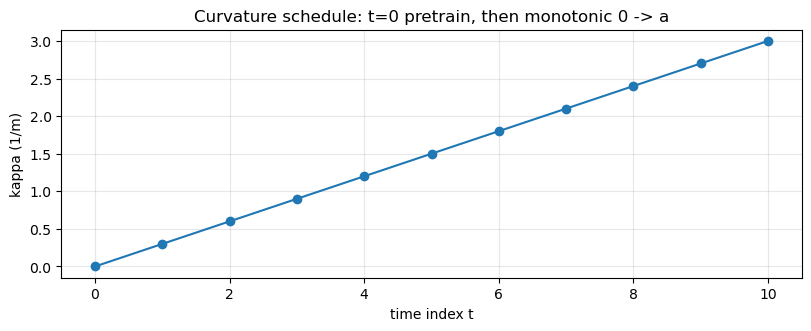

In [5]:
dynamic_kappas = make_dynamic_kappas(cfg)
kappa_by_time = np.concatenate([[0.0], dynamic_kappas]).astype(np.float32)
counts_by_time = np.concatenate([
    [cfg["pretrain_samples"]],
    np.full(cfg["dynamic_steps"], cfg["samples_per_dynamic_state"], dtype=np.int64),
])

print("time states:", len(kappa_by_time))
print("counts_by_time:", counts_by_time.tolist())
print("kappa_by_time:", np.round(kappa_by_time, 4).tolist())
print("total samples:", int(counts_by_time.sum()))

fig, ax1 = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
ax1.plot(np.arange(len(kappa_by_time)), kappa_by_time, marker="o")
ax1.set_xlabel("time index t")
ax1.set_ylabel("kappa (1/m)")
ax1.set_title("Curvature schedule: t=0 pretrain, then monotonic 0 -> a")
ax1.grid(True, alpha=0.3)
plt.show()

solved modes: 2145
projector: cho, seconds=10.72
kept modes: 1500
M shape: (10000, 1500) complex64 approx GB: 0.12
target side px for embedded 16x16 input: 50
setup seconds: 25.41


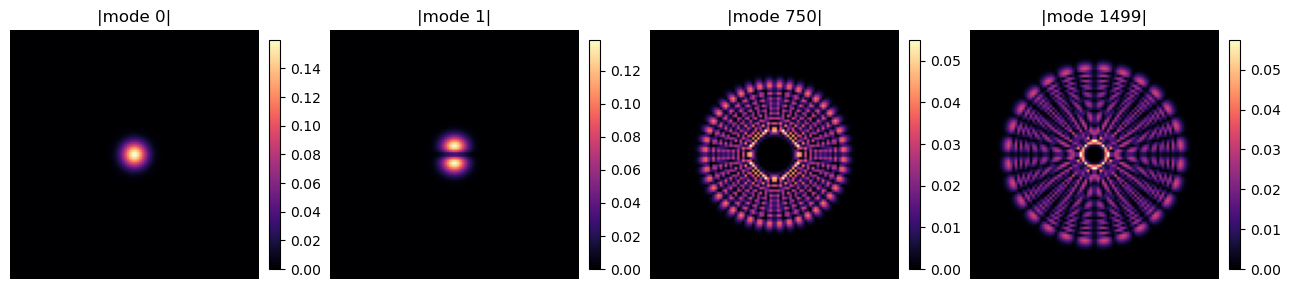

In [6]:
t0 = time.time()
profile, modes = solve_modes(cfg)
M, fast_builder = build_mode_matrix_and_fast_builder(modes, cfg)
projector = make_projector(M, cfg)

print("kept modes:", modes.number)
print("M shape:", M.shape, M.dtype, "approx GB:", round(M.nbytes / 1e9, 3))
if not np.isfinite(M).all():
    raise ValueError("Mode matrix contains NaN or Inf values after keeping the requested modes.")
print("target side px for embedded 16x16 input:", make_target_side_px(profile, cfg))
print("setup seconds:", round(time.time() - t0, 2))

if RUN_MODE == "full":
    assert modes.number == 1500
    assert cfg["input_grid"] == 16
    assert cfg["output_grid"] == 100

# Quick mode visualization.
mode_indices = [0, min(1, modes.number - 1), modes.number // 2, modes.number - 1]
fig, axes = plt.subplots(1, len(mode_indices), figsize=(3.2 * len(mode_indices), 3), constrained_layout=True)
for ax, idx in zip(np.atleast_1d(axes), mode_indices):
    mode_img = np.abs(M[:, idx].reshape(cfg["npoints"], cfg["npoints"]))
    im = ax.imshow(mode_img, cmap="magma")
    ax.set_title(f"|mode {idx}|")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

In [8]:
def generate_dataset(cfg, profile, modes, M, projector, fast_builder, kappa_by_time, counts_by_time):
    out_dir = prepare_output_dir(cfg)
    total = int(counts_by_time.sum())
    output_grid = cfg["output_grid"]

    patterns_mm = np.lib.format.open_memmap(
        out_dir / "pattern.npy", mode="w+", dtype=np.uint8, shape=(total, cfg["input_grid"] * cfg["input_grid"])
    )
    speckles_mm = np.lib.format.open_memmap(
        out_dir / "speckles.npy", mode="w+", dtype=np.uint8, shape=(total, output_grid, output_grid)
    )
    time_mm = np.lib.format.open_memmap(out_dir / "time_index.npy", mode="w+", dtype=np.int16, shape=(total,))
    kappa_mm = np.lib.format.open_memmap(out_dir / "kappa_per_sample.npy", mode="w+", dtype=np.float32, shape=(total,))
    np.save(out_dir / "kappa_by_time.npy", kappa_by_time.astype(np.float32))
    np.save(out_dir / "counts_by_time.npy", counts_by_time.astype(np.int64))

    metadata = {
        "run_mode": RUN_MODE,
        "created_unix": time.time(),
        "config": {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()},
        "data_schema": {
            "pattern.npy": [total, cfg["input_grid"] * cfg["input_grid"]],
            "speckles.npy": [total, output_grid, output_grid],
            "time_index.npy": [total],
            "kappa_per_sample.npy": [total],
        },
        "mmdn_training_hint": {
            "speckle_dim": int(output_grid),
            "sizeOfPretrain": int(cfg["pretrain_samples"]),
            "sizeOfBatch": int(cfg["samples_per_dynamic_state"]),
            "sizeOfUpdateInvertal": int(cfg["samples_per_dynamic_state"]),
        },
        "note": "M, Tm, and modal coefficients were not written to disk; they were generated in memory only.",
    }
    with open(out_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    tm_cache = {}

    def get_propagator(kappa):
        key = round(float(kappa), 8)
        if key not in tm_cache:
            tm_cache[key] = compute_dense_tm(modes, fast_builder, key, cfg)
        return tm_cache[key]

    offset = 0
    rng = np.random.default_rng(RANDOM_SEED)
    outer = tqdm(enumerate(zip(kappa_by_time, counts_by_time)), total=len(kappa_by_time), desc="time states")
    for t_idx, (kappa, n_samples) in outer:
        n_samples = int(n_samples)
        propagator = get_propagator(float(kappa))
        for local_start in tqdm(range(0, n_samples, cfg["batch_size"]), leave=False, desc=f"t={t_idx}"):
            n = min(cfg["batch_size"], n_samples - local_start)
            patterns = make_pattern_batch(rng, n, cfg)
            speckles = speckles_from_patterns(patterns, profile, M, projector, propagator, cfg)
            sl = slice(offset + local_start, offset + local_start + n)
            patterns_mm[sl] = patterns.reshape(n, -1)
            speckles_mm[sl] = speckles
            time_mm[sl] = t_idx
            kappa_mm[sl] = float(kappa)
        offset += n_samples
        patterns_mm.flush()
        speckles_mm.flush()
        time_mm.flush()
        kappa_mm.flush()

    del patterns_mm, speckles_mm, time_mm, kappa_mm
    return out_dir


t0 = time.time()
out_dir = generate_dataset(cfg, profile, modes, M, projector, fast_builder, kappa_by_time, counts_by_time)
print("dataset written:", out_dir)
print("elapsed seconds:", round(time.time() - t0, 2))

time states:   0%|          | 0/11 [00:00<?, ?it/s]

t=0:   0%|          | 0/782 [00:00<?, ?it/s]

t=1:   0%|          | 0/40 [00:00<?, ?it/s]

t=2:   0%|          | 0/40 [00:00<?, ?it/s]

t=3:   0%|          | 0/40 [00:00<?, ?it/s]

...

t=7:   0%|          | 0/40 [00:00<?, ?it/s]

t=8:   0%|          | 0/40 [00:00<?, ?it/s]

t=9:   0%|          | 0/40 [00:00<?, ?it/s]

t=10:   0%|          | 0/40 [00:00<?, ?it/s]

dataset written: E:\Research\speckel&input\mmdn_dynamic_1500m_16x16_100x100
elapsed seconds: 925.22


In [ ]:
out_dir = Path(cfg["out_dir"])
pattern = np.load(out_dir / "pattern.npy", mmap_mode="r")
speckles = np.load(out_dir / "speckles.npy", mmap_mode="r")
time_index = np.load(out_dir / "time_index.npy", mmap_mode="r")
kappa_per_sample = np.load(out_dir / "kappa_per_sample.npy", mmap_mode="r")

print("pattern:", pattern.shape, pattern.dtype, "unique first sample:", np.unique(pattern[0]))
print("speckles:", speckles.shape, speckles.dtype, "min/max:", int(speckles[: min(512, len(speckles))].min()), int(speckles[: min(512, len(speckles))].max()))
print("time_index:", time_index.shape, time_index.dtype)
print("kappa_per_sample:", kappa_per_sample.shape, kappa_per_sample.dtype)

unique_t, counts = np.unique(time_index, return_counts=True)
print("counts by t:", dict(zip(unique_t.tolist(), counts.tolist())))
assert pattern.shape == (cfg["total_samples"], 256)
assert speckles.shape == (cfg["total_samples"], cfg["output_grid"], cfg["output_grid"])
assert int(counts[0]) == cfg["pretrain_samples"]
print("validation passed")

pattern: (150000, 256) uint8 unique first sample: [0 1]
speckles: (150000, 100, 100) uint8 min/max: 0 255
time_index: (150000,) int16
kappa_per_sample: (150000,) float32
counts by t: {0: 100000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000, 10: 5000}
validation passed


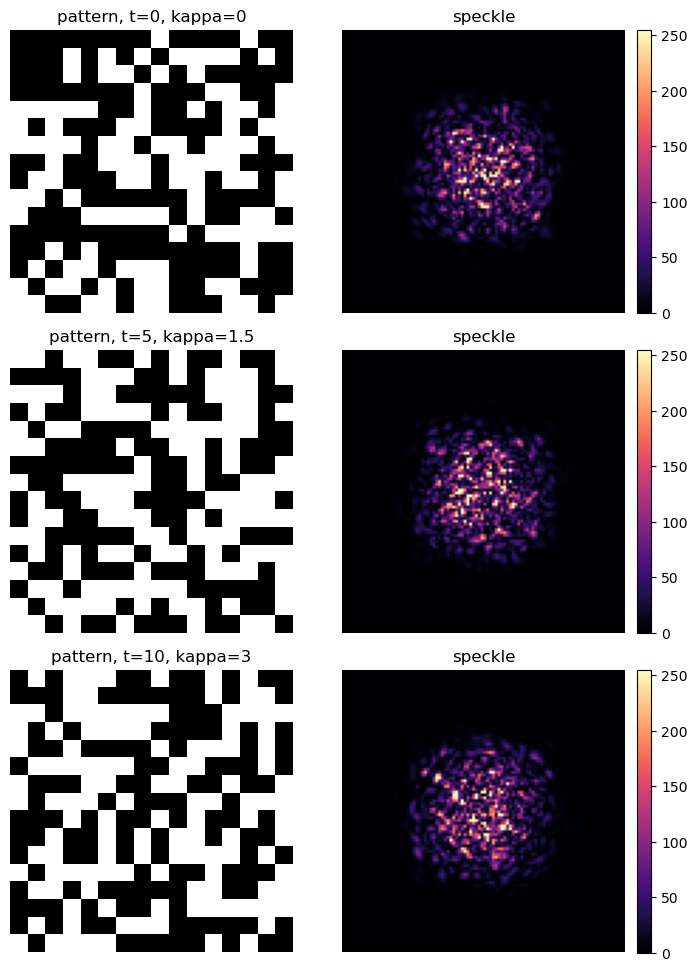

saved preview: E:\Research\speckel&input\mmdn_dynamic_1500m_16x16_100x100\preview_patterns_speckles.png


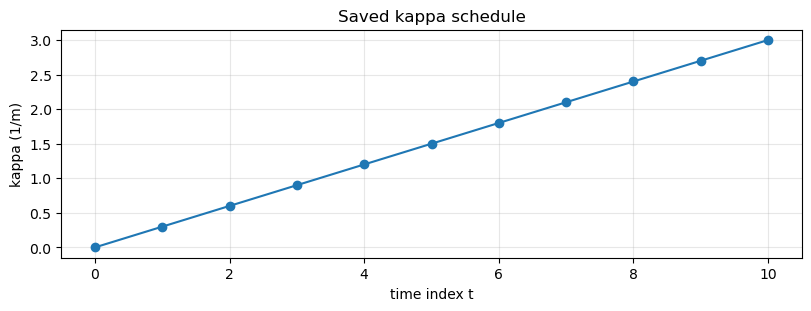

In [ ]:
# Visualization: input patterns and speckles from several time states.
out_dir = Path(cfg["out_dir"])
pattern = np.load(out_dir / "pattern.npy", mmap_mode="r")
speckles = np.load(out_dir / "speckles.npy", mmap_mode="r")
time_index = np.load(out_dir / "time_index.npy", mmap_mode="r")
kappa_by_time = np.load(out_dir / "kappa_by_time.npy")

selected_t = [0, len(kappa_by_time) // 2, len(kappa_by_time) - 1]
selected_indices = []
for t_idx in selected_t:
    idx = np.flatnonzero(time_index == t_idx)[0]
    selected_indices.append(int(idx))

fig, axes = plt.subplots(len(selected_indices), 2, figsize=(7, 3.2 * len(selected_indices)), constrained_layout=True)
axes = np.atleast_2d(axes)
for row, (idx, t_idx) in enumerate(zip(selected_indices, selected_t)):
    pat = pattern[idx].reshape(cfg["input_grid"], cfg["input_grid"])
    spk = speckles[idx]

    axes[row, 0].imshow(pat, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[row, 0].set_title(f"pattern, t={t_idx}, kappa={kappa_by_time[t_idx]:.3g}")
    axes[row, 0].axis("off")

    im = axes[row, 1].imshow(spk, cmap="magma", vmin=0, vmax=255)
    axes[row, 1].set_title("speckle")
    axes[row, 1].axis("off")
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

preview_path = out_dir / "preview_patterns_speckles.png"
fig.savefig(preview_path, dpi=160)
plt.show()
print("saved preview:", preview_path)

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(np.arange(len(kappa_by_time)), kappa_by_time, marker="o")
ax.set_xlabel("time index t")
ax.set_ylabel("kappa (1/m)")
ax.set_title("Saved kappa schedule")
ax.grid(True, alpha=0.3)
fig.savefig(out_dir / "preview_kappa_schedule.png", dpi=160)
plt.show()

In [ ]:
# Recommended MMDN training arguments.
out_dir = Path(cfg["out_dir"]).resolve()
cmd = (
    f'python MMDN.py --datafolder "{out_dir}" '
    f'--speckle_dim {cfg["output_grid"]} '
    f'--sizeOfPretrain {cfg["pretrain_samples"]} '
    f'--sizeOfBatch {cfg["samples_per_dynamic_state"]} '
    f'--sizeOfUpdateInvertal {cfg["samples_per_dynamic_state"]}'
)
print(cmd)
with open(out_dir / "mmdn_train_command.txt", "w", encoding="utf-8") as f:
    f.write(cmd + "\n")

python MMDN.py --datafolder "E:\Research\speckel&input\mmdn_dynamic_1500m_16x16_100x100" --speckle_dim 100 --sizeOfPretrain 100000 --sizeOfBatch 5000 --sizeOfUpdateInvertal 5000
